# T2

In [482]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import seaborn as sns
import math as mt
from skimage.io import imread, imsave
from matplotlib import pyplot as plt

np.random.seed(42)

In [483]:
n = 25
N=1000


def MuK(k, x):
    return np.sum([(x_i - np.mean(x))**k for x_i in x]) / len(x)

def p(x):
    return np.exp(-x) if x>=0 else 0

def F(x):
    return 1-np.exp(-x) if x>=0 else 0

def bootstrap_mean(x, N=1000): # бутстрап для средних
    bootstrap_means = []
    n = len(x)
    for _ in range(N):
        bt_sample = np.random.choice(x, size=n, replace=True)
        bootstrap_means+=[np.mean(bt_sample)]
    return np.array(bootstrap_means)

def bootstrap_assym(x, N=1000): # бутстрап для коэффициента ассиметрии
    bootstrap_assyms = []
    n = len(x)
    for _ in range(N):
        bt_sample = np.random.choice(x, size=n, replace=True)
        bootstrap_assyms+=[st.skew(bt_sample)]
    return np.array(bootstrap_assyms)

def bootstrap_medians(x, N=1000): # бутстрап для медианы
    bootstrap_meds = []
    n = len(x)
    for _ in range(N):
        bt_sample = np.random.choice(x, size=n, replace=True)
        bootstrap_meds+=[np.median(bt_sample)]
    return np.array(bootstrap_meds)

k = n // 2 + 1 # порядковая статистика медианы

def dens_kth_stat(x):
    return p(x) * (mt.factorial(n)/(mt.factorial(k-1)*mt.factorial(n-k))) * ((1-F(x)) ** (n-k)) * (F(x) ** (k - 1))    

def norm(x, m, D):
    return 1/(np.sqrt(2*np.pi*D))*np.exp(-(x-m)**2/(2*D))


### Генерация выборки

In [484]:
X = st.expon(scale=1).rvs(size=n) #scale = 1/lambda, в нашем случае лямбда это 1, ниже честно это докажу
ord_X = np.sort(X) # вариационный ряд
X

array([0.46926809, 3.01012143, 1.31674569, 0.91294255, 0.16962487,
       0.16959629, 0.05983877, 2.01123086, 0.91908215, 1.23125006,
       0.02079931, 3.50355748, 1.78642954, 0.23868763, 0.20067899,
       0.20261142, 0.36275373, 0.74392783, 0.56553707, 0.34422299,
       0.94637087, 0.15023453, 0.34551551, 0.45627722, 0.60893469])

### a) Мода, медиана, размах, коэфф. ассиметрии

In [485]:
X_ = list(ord_X) # для удобства работы с методом count
mode = X_[max([(X_.count(X_[i]), i) for i in range(n)])[-1]] if n != len(set(X_)) else "Every element in selection is mode"
q2 = float(np.median(X_))
l = float(ord_X.max() - ord_X.min())
gamma = float(MuK(3,X)/(MuK(2,X)**1.5)) # или из scipy.stats st.skew(X) 

ans_a = {"Мода":mode,"Медиана":q2,"Размах":l,"Коэффициент ассиметрии":gamma}
ans_a

{'Мода': 'Every element in selection is mode',
 'Медиана': 0.4692680899768591,
 'Размах': 3.4827581671591736,
 'Коэффициент ассиметрии': 1.6998221113390404}

### b) Эмперическая функция распределения

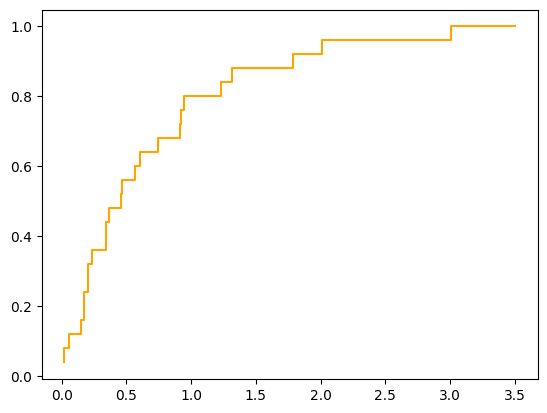

In [486]:
plt.step(ord_X, np.arange(1,1+n)/n, color='orange', linestyle='-') # для ступенчатой функции (эмперическая функция распределения и является таковой)
plt.show()

### Гистограмма

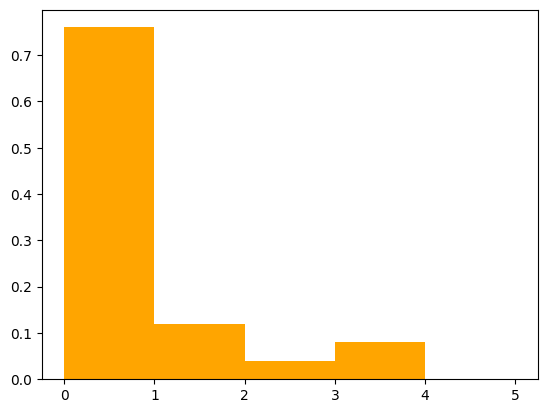

In [487]:
plt.hist(ord_X, bins=int(np.log2(n))+1,range=(0,5),density=True,color='orange') # гистограмма
plt.show()

### Boxplot

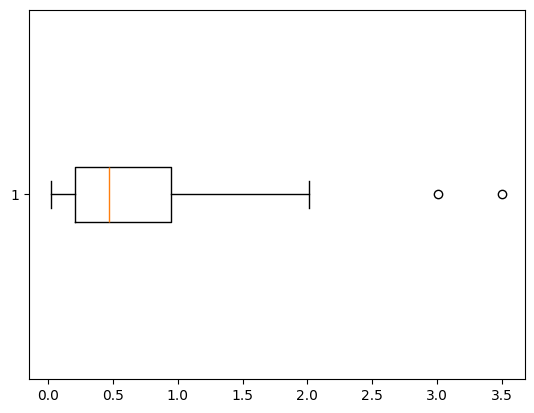

In [488]:
plt.boxplot(X,orientation='horizontal')
plt.show()

### c) Сравнить оценку плотности среднего арифметического элементов выборки, полученную с помощью ЦПТ, с бутстраповской оценкой этой плотности

![](T2c.jpg)



<Axes: >

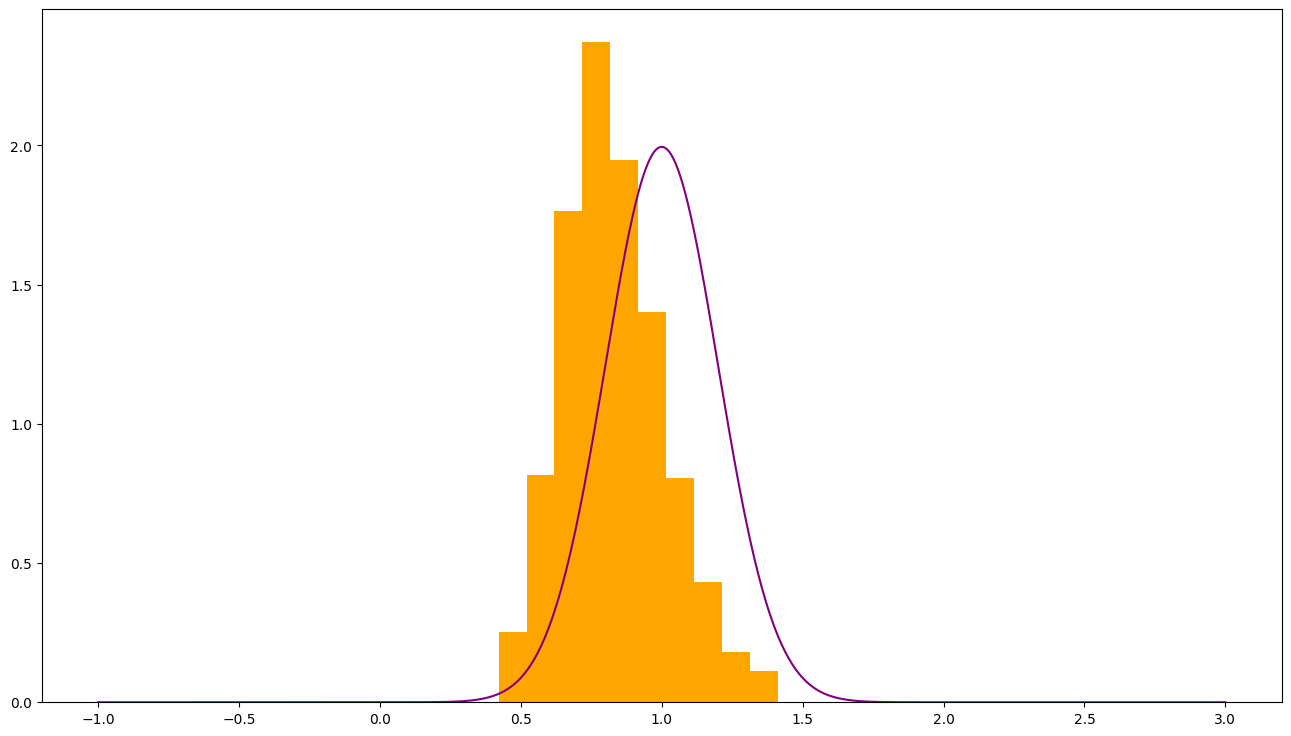

In [489]:
m_ksi = 1
D_ksi = 1/25

fig, axs = plt.subplots(1,1,figsize=(16,9))
bt = bootstrap_mean(X, N)
axs.hist(bt, bins = int(np.log2(N))+1, color='orange', density=True)
x = np.linspace(-1,3,1000)
norm_x = norm(x,m_ksi, D_ksi)
axs.plot(x,norm_x,color='purple')
axs

### d) Найти бутстраповскую оценку плотности распределения коэффициента ассиметрии и оценить вероятность того, что коэффициент ассиметрии будет меньше 1

<Axes: >

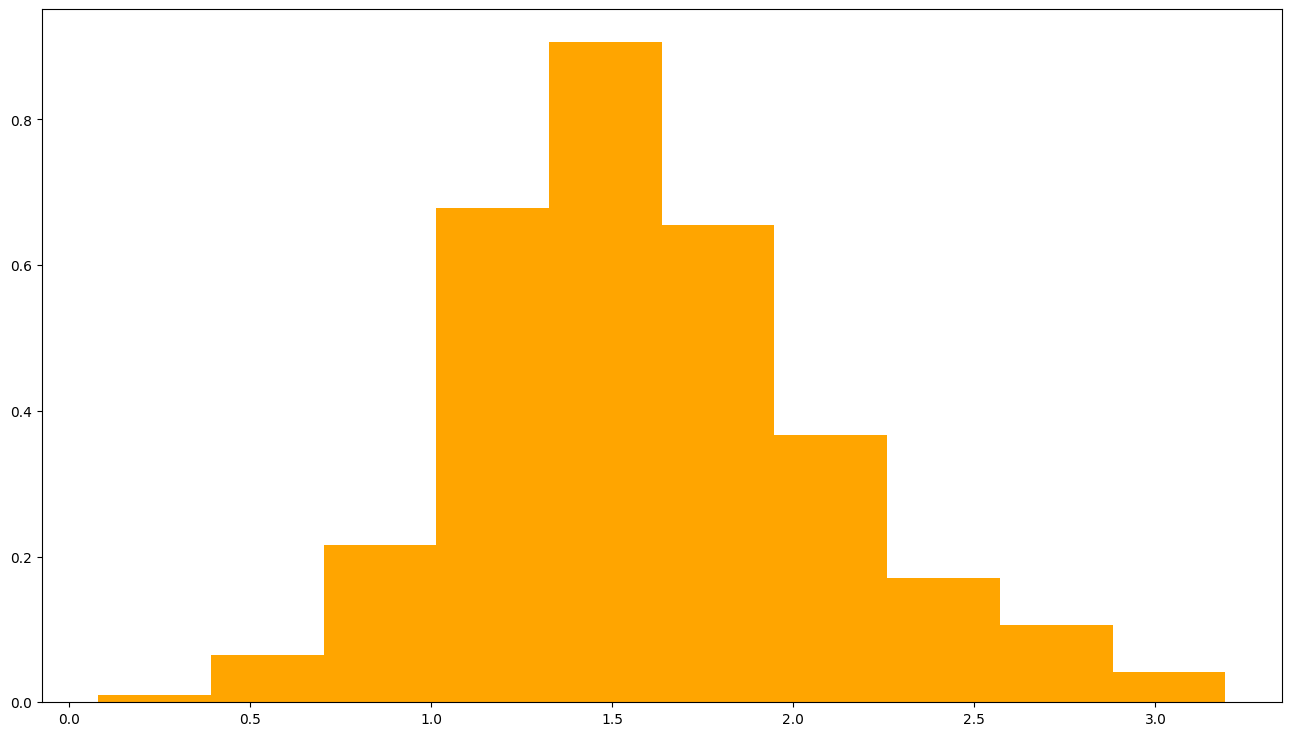

In [490]:
fig, axs = plt.subplots(1,1,figsize=(16,9))
bt = bootstrap_assym(X, N)
axs.hist(bt, bins = int(np.log2(N)+1), color='orange', density=True)
axs

In [491]:
p_assym = np.sum([1 if bt[i] < 1 else 0 for i in range(len(bt))])/N #по сути кол-во элементов меньших 1 в бутстраповской оценке
float(p_assym)

0.088

### e) Сравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности

<Axes: >

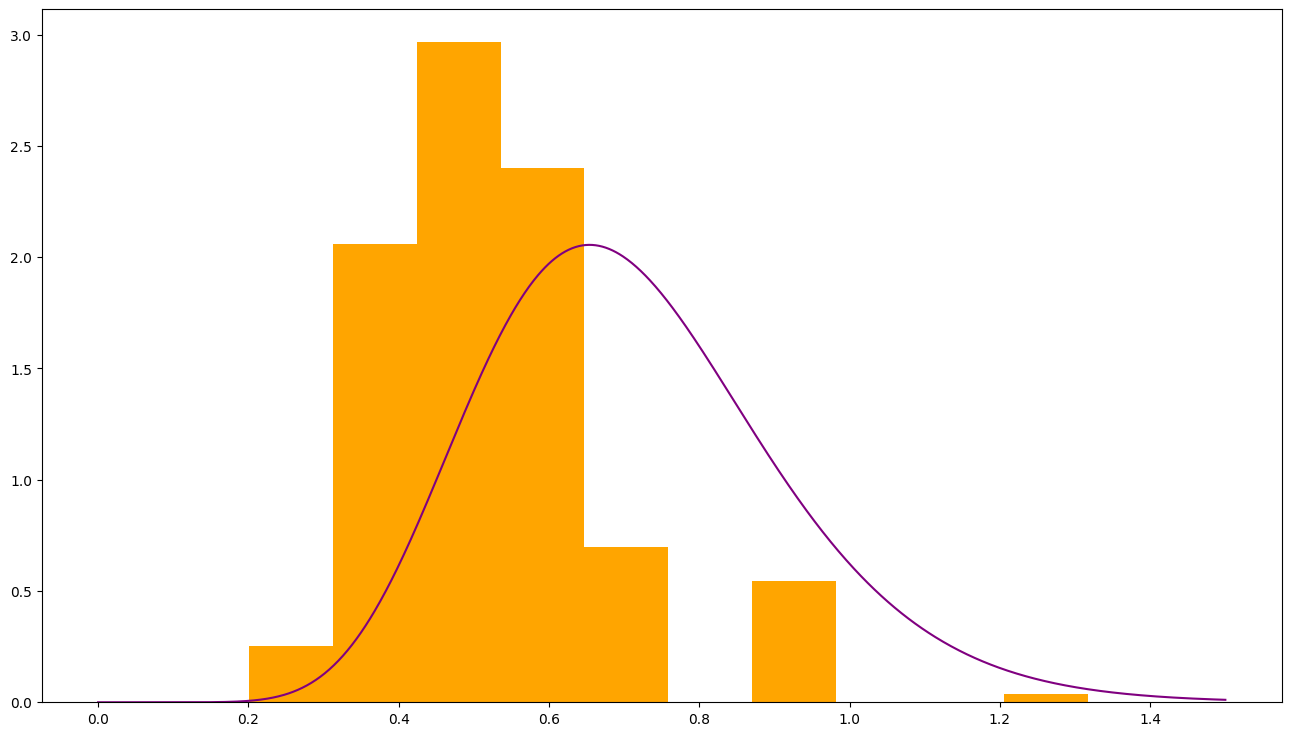

In [497]:
fig, axs = plt.subplots(1,1,figsize=(16,9))
bt = bootstrap_medians(X, N)
axs.hist(bt, bins = int(np.log2(N))+1, color='orange', density=True)
x = np.linspace(0, 1.5, 1000)
y = [dens_kth_stat(x[i]) for i in range(len(x))]
axs.plot(x,y,color='purple')
axs